## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
title_df = pd.read_csv('titles.csv')
credit_df = pd.read_csv('credits.csv')

### Dataset First View

In [3]:
title_df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [4]:
credit_df.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [5]:
title_df.shape

(9871, 15)

In [6]:
print("Number of rows and columns in title dataset")
print("Number of rows:-",title_df.shape[0])
print("Number of columns:-",title_df.shape[1])

Number of rows and columns in title dataset
Number of rows:- 9871
Number of columns:- 15


In [7]:
credit_df.shape

(124235, 5)

In [8]:
print("Number of rows and columns in credit dataset")
print("Number of rows:-",credit_df.shape[0])
print("Number of columns:-",credit_df.shape[1])

Number of rows and columns in credit dataset
Number of rows:- 124235
Number of columns:- 5


### Dataset Information

In [9]:
title_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [10]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


#### Duplicate Values

In [11]:
title_df.duplicated().sum()

np.int64(3)

In [12]:
credit_df.duplicated().sum()

np.int64(56)

#### Missing Values/Null Values

In [13]:
title_df.isnull().sum()

id                         0
title                      0
type                       0
description              119
release_year               0
age_certification       6487
runtime                    0
genres                     0
production_countries       0
seasons                 8514
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2082
dtype: int64

In [14]:
credit_df.isnull().sum()

person_id        0
id               0
name             0
character    16287
role             0
dtype: int64

## What information did we grab from the dataset?

## Dataset Overview

As part of the initial exploratory data analysis (EDA), the structure and quality of both datasets were examined.

### Dataset Dimensions

- **title_df** contains **9,871 rows** and **15 columns**.
- **credit_df** contains **124,235 rows** and **5 columns**.

### Duplicate Records

A check for duplicate entries revealed:

| Dataset | Number of Duplicate Records |
|----------|----------------------------|
| title_df | 3 |
| credit_df | 56 |

### Missing Values Analysis

The following columns were found to contain missing (null) values:

| Column | Missing Values |
|----------|--------------:|
| description | 119 |
| age_certification | 6,487 |
| seasons | 8,514 |
| imdb_id | 667 |
| imdb_score | 1,021 |
| imdb_votes | 1,031 |
| tmdb_popularity | 547 |
| tmdb_score | 2,082 |
| character | 16,287 |

### Key Observations

- The datasets contain a relatively small number of duplicate records, which can be removed during the data-cleaning phase.
- Several features, particularly **age_certification**, **seasons**, and **character**, have a significant number of missing values and may require appropriate imputation or handling strategies.
- Understanding and addressing these data quality issues is essential before proceeding with further analysis and model development.

## ***2. Understanding Your Variables***

In [15]:
title_df.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [16]:
credit_df.columns

Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')

In [17]:
title_df.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


In [18]:
credit_df.describe()

,person_id
count,1.242350e+05
mean,4.064737e+05
std,5.616296e+05
min,1.000000e+00
25%,3.899200e+04
50%,1.339490e+05
75%,5.712560e+05
max,2.371153e+06


## Variables Description

This project utilizes two datasets, **`titles.csv`** and **`credits.csv`**, which together provide detailed information about the content available on Amazon Prime Video.

### Titles Dataset (`titles.csv`)

The **titles** dataset contains information related to movies and TV shows available on the platform. Key variables include:

- **title** – Name of the movie or TV show.
- **type** – Content category (Movie or Show).
- **release_year** – Year of release.
- **runtime** – Duration of the content in minutes.
- **genres** – Genre classification of the content.
- **age_certification** – Recommended age rating.
- **production_countries** – Countries involved in production.
- **imdb_score** – IMDb rating score.
- **tmdb_popularity** – Popularity score obtained from TMDb.

These variables help in understanding content characteristics, release patterns, genre trends, audience preferences, and overall content performance.

### Credits Dataset (`credits.csv`)

The **credits** dataset contains information about the individuals involved in creating and performing in the content. Important variables include:

- **name** – Name of the contributor.
- **character** – Character portrayed by the actor.
- **role** – Contributor's role, such as Actor, Director, or Writer.

This dataset enables the analysis of cast and crew participation, contributor frequency, and the relationship between creative talent and content success.

### Purpose of the Datasets

By combining information from both datasets, it becomes possible to perform a comprehensive analysis of Amazon Prime's content library. The data supports investigations into:

- Content distribution across movies and TV shows.
- Trends in release years and genres.
- Audience ratings and content popularity.
- Production patterns across different countries.
- Contributions of actors, directors, and writers.
- Relationships between content characteristics and viewer reception.

Together, these datasets provide valuable insights into the composition, quality, and performance of content available on Amazon Prime Video.

### Check Unique Values for each variable.

In [19]:
title_df.nunique()

id                      9868
title                   9737
type                       2
description             9734
release_year             110
age_certification         11
runtime                  207
genres                  2028
production_countries     497
seasons                   32
imdb_id                 9201
imdb_score                86
imdb_votes              3650
tmdb_popularity         5325
tmdb_score                89
dtype: int64

In [20]:
credit_df.nunique()

person_id    80508
id            8861
name         79758
character    71097
role             2
dtype: int64

## 3. ***Data Wrangling***

In [21]:
# Replace NaN values in age_certification with 'Not Rated'
title_df['age_certification'] = title_df['age_certification'].fillna('Not Rated')

# Replace NaN values in imdb_score with the mean imdb_score
title_df['imdb_score'] = title_df['imdb_score'].fillna(title_df['imdb_score'].mean())

In [22]:
# Remove duplicate rows
title_df = title_df.drop_duplicates()
credit_df = credit_df.drop_duplicates()

In [23]:
# Merge datasets on 'id'
merged_df = title_df.merge(credit_df, on='id', how='left')


In [24]:
# Create decade column
merged_df['decade'] = (merged_df['release_year'] // 10) * 10

In [25]:
# Categorize runtime
merged_df['runtime_category'] = pd.cut(merged_df['runtime'],bins=[0, 30, 90, float('inf')],labels=['Short', 'Medium', 'Long'],include_lowest=True)

# Create is_movie column (1 for MOVIE, 0 for SHOW)
merged_df['is_movie'] = (merged_df['type'] == 'MOVIE').astype(int)

In [26]:
#Categorize IMDb ratings (Poor, Average, Good, Excellent)
merged_df['rating_category'] = ''
for i in range(len(merged_df)):
    score = merged_df.loc[i, 'imdb_score']
    if pd.isna(score):
        merged_df.loc[i, 'rating_category'] = 'Not Rated'
    elif score < 5:
        merged_df.loc[i, 'rating_category'] = 'Poor'
    elif score < 7:
        merged_df.loc[i, 'rating_category'] = 'Average'
    elif score < 8.5:
        merged_df.loc[i, 'rating_category'] = 'Good'
    else:
        merged_df.loc[i, 'rating_category'] = 'Excellent'


## ***4. KPIs ( Key Performance Indicators) Calculation***

### General Content Overview KPIs

In [27]:
total_titles = merged_df.shape[0]
total_movies = merged_df[merged_df['type'] == 'MOVIE'].shape[0]
total_shows = merged_df[merged_df['type'] == 'SHOW'].shape[0]
avg_runtime = merged_df['runtime'].mean()
avg_imdb = merged_df['imdb_score'].mean()
oldest_year = merged_df['release_year'].min()
newest_year = merged_df['release_year'].max()

print("Total Titles:", total_titles)
print("Movies:", total_movies)
print("Shows:", total_shows)
print("Average Runtime:", round(avg_runtime, 2))
print("Average IMDb Score:", round(avg_imdb, 2))
print("Release Years Range:", oldest_year, "-", newest_year)

Total Titles: 125186
Movies: 116685
Shows: 8501
Average Runtime: 95.35
Average IMDb Score: 5.97
Release Years Range: 1912 - 2022


### Genre Based KPIs

In [28]:
# Split multiple genres into separate rows
genres_split = merged_df.dropna(subset=['genres']).copy()
genres_split['genres'] = genres_split['genres'].str.replace('[', '').str.replace(']', '').str.replace("'", "")
genres_split = genres_split.assign(genres=genres_split['genres'].str.split(','))
genres_split = genres_split.explode('genres')
genres_split['genres'] = genres_split['genres'].str.strip()

In [29]:
# Top 10 genres
top_genres = genres_split['genres'].value_counts().head(10)
print(top_genres)

genres
drama       70006
comedy      41493
thriller    33079
action      30400
romance     28633
crime       20618
horror      14142
european    12548
scifi       11442
fantasy      8935
Name: count, dtype: int64


In [30]:
# Average IMDb by genre
avg_imdb_genre = genres_split.groupby('genres')['imdb_score'].mean().sort_values(ascending=False).head(10)
print(avg_imdb_genre)

genres
documentation    6.874880
history          6.682058
reality          6.573309
war              6.429377
animation        6.380818
european         6.336190
sport            6.256898
drama            6.228907
romance          6.121547
music            6.116504
Name: imdb_score, dtype: float64


### Ratings & Quality KPIs

In [31]:
# Average IMDb and TMDB
avg_imdb = merged_df['imdb_score'].mean()
avg_tmdb = merged_df['tmdb_score'].mean()
print("Average IMDb:", round(avg_imdb,2), "Average TMDB:", round(avg_tmdb,2))
print()
# Top 10 highest rated
top_rated = merged_df.sort_values('imdb_score', ascending=False).head(10)
print(top_rated[['title', 'imdb_score']])
print()
# Correlation between IMDb and TMDB
correlation = merged_df['imdb_score'].corr(merged_df['tmdb_score'])
print("Correlation IMDb vs TMDB:", round(correlation,2))

Average IMDb: 5.97 Average TMDB: 5.99

             title  imdb_score
119803  Pawankhind         9.9
119799  Pawankhind         9.9
119807  Pawankhind         9.9
119798  Pawankhind         9.9
119809  Pawankhind         9.9
119801  Pawankhind         9.9
119797  Pawankhind         9.9
119808  Pawankhind         9.9
119805  Pawankhind         9.9
119815  Pawankhind         9.9

Correlation IMDb vs TMDB: 0.62


### Cast and Crew KPIs

In [32]:
# Top actors, directors, and writers
top_actors = merged_df[merged_df['role'] == 'ACTOR']['name'].value_counts().head(10)
top_directors = merged_df[merged_df['role'] == 'DIRECTOR']['name'].value_counts().head(10)
top_writers = merged_df[merged_df['role'] == 'WRITER']['name'].value_counts().head(10)

print("Top Actors:\n", top_actors)
print()
print("Top Directors:\n", top_directors)
print()
# Role distribution
role_dist = merged_df['role'].value_counts()
print(role_dist)

Top Actors:
 name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Gene Autry              40
Nassar                  37
Herman Hack             35
Charles King            35
Forrest Taylor          34
George Morrell          34
Earl Dwire              34
Name: count, dtype: int64

Top Directors:
 name
Joseph Kane           41
Sam Newfield          38
Jay Chapman           34
Lesley Selander       22
John English          21
Harry L. Fraser       21
William Nigh          20
Manny Rodriguez       17
Robert N. Bradbury    17
William Beaudine      16
Name: count, dtype: int64

role
ACTOR       115793
DIRECTOR      8386
Name: count, dtype: int64


### Country and Regional KPIs

In [33]:
# Split production countries
countries_split = merged_df.dropna(subset=['production_countries']).copy()
countries_split['production_countries'] = countries_split['production_countries'].str.replace('[', '').str.replace(']', '').str.replace("'", "")
countries_split = countries_split.assign(production_countries=countries_split['production_countries'].str.split(','))
countries_split = countries_split.explode('production_countries')
countries_split['production_countries'] = countries_split['production_countries'].str.strip()

# Top 10 countries
top_countries = countries_split['production_countries'].value_counts().head(10)
print(top_countries)

production_countries
US    79111
GB    12574
IN    11591
CA     6625
FR     4861
DE     3219
       2745
JP     2650
IT     2578
AU     2195
Name: count, dtype: int64


### Age Certification KPIs

In [34]:
# Count of each certification
cert_count = merged_df['age_certification'].value_counts()
print(cert_count)
print()
# Average IMDb by certification
avg_imdb_cert = merged_df.groupby('age_certification')['imdb_score'].mean().sort_values(ascending=False)
print(avg_imdb_cert)


age_certification
Not Rated    68329
R            25941
PG-13        12506
PG            9641
G             3845
TV-MA         1743
TV-14         1605
TV-PG          519
TV-Y7          365
TV-Y           320
TV-G           255
NC-17          117
Name: count, dtype: int64

age_certification
TV-PG        7.454458
TV-MA        7.357626
TV-14        7.234761
TV-Y7        6.738242
TV-G         6.634831
TV-Y         6.410660
PG-13        6.107513
PG           6.102564
G            6.039746
R            5.923611
Not Rated    5.858963
NC-17        5.300653
Name: imdb_score, dtype: float64


### Popularity and Engagement KPIs

In [35]:
# Top 10 popular titles
top_popular = merged_df.sort_values('tmdb_popularity', ascending=False).head(10)
print(top_popular[['title', 'tmdb_popularity']])
print()
# Correlation between popularity & IMDb
popularity_corr = merged_df['tmdb_popularity'].corr(merged_df['imdb_score'])
print("Correlation between TMDB Popularity and IMDb Rating:", round(popularity_corr,2))

                     title  tmdb_popularity
116580  All the Old Knives         1437.906
116595  All the Old Knives         1437.906
116579  All the Old Knives         1437.906
116591  All the Old Knives         1437.906
116574  All the Old Knives         1437.906
116578  All the Old Knives         1437.906
116593  All the Old Knives         1437.906
116581  All the Old Knives         1437.906
116582  All the Old Knives         1437.906
116583  All the Old Knives         1437.906

Correlation between TMDB Popularity and IMDb Rating: 0.07


### Time and Trends KPIs

In [36]:
# Number of releases per year
release_trend = merged_df['release_year'].value_counts().sort_index()

# Average IMDb score per year
avg_imdb_year = merged_df.groupby('release_year')['imdb_score'].mean()

print("Number of Releases per Year:")
print(release_trend)

print("\nAverage IMDb Score per Year:")
print(avg_imdb_year)

Number of Releases per Year:
release_year
1912      11
1914      33
1915      53
1916     126
1917       8
        ... 
2018    7003
2019    8559
2020    7052
2021    7693
2022    1001
Name: count, Length: 110, dtype: int64

Average IMDb Score per Year:
release_year
1912    5.800000
1914    5.521212
1915    6.088679
1916    7.483333
1917    6.300000
          ...   
2018    5.859943
2019    5.898901
2020    5.706695
2021    5.705211
2022    6.483340
Name: imdb_score, Length: 110, dtype: float64


### Derived KPIs (from feature engineered columns)

In [37]:
# Average runtime by runtime category
avg_runtime_category = merged_df.groupby('runtime_category')['runtime'].mean()
print(avg_runtime_category)
print()
# Average IMDb by rating category
avg_rating_category = merged_df.groupby('rating_category')['imdb_score'].mean()
print(avg_rating_category)

runtime_category
Short      22.389107
Medium     74.961706
Long      113.521213
Name: runtime, dtype: float64

rating_category
Average      5.991743
Excellent    8.729434
Good         7.474342
Poor         4.087871
Name: imdb_score, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_16160\1273098322.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_runtime_category = merged_df.groupby('runtime_category')['runtime'].mean()


## ***5. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Movies Vs TV Shows Count

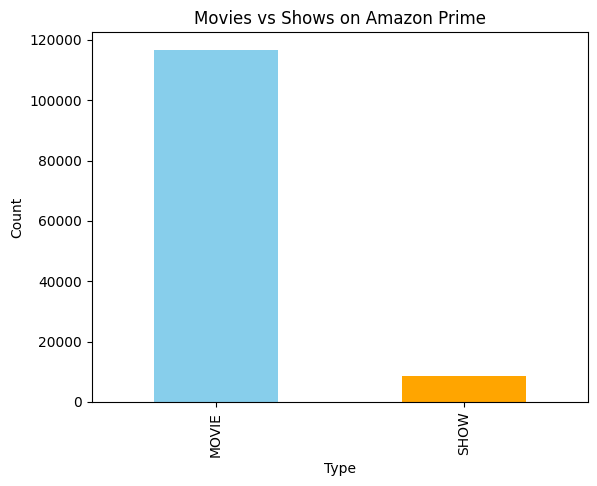

In [38]:
# Movies vs Shows
merged_df['type'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Movies vs Shows on Amazon Prime')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

#### Chart - 2 Releases by Year

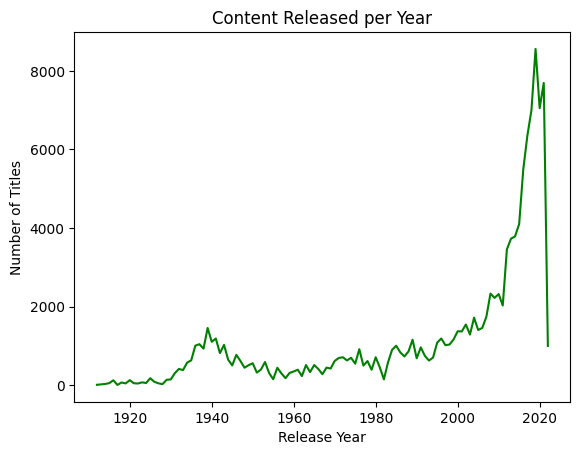

In [39]:
# Releases by Year
merged_df['release_year'].value_counts().sort_index().plot(kind='line', color='green')
plt.title('Content Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

#### Chart - 3 Runtime Distribution

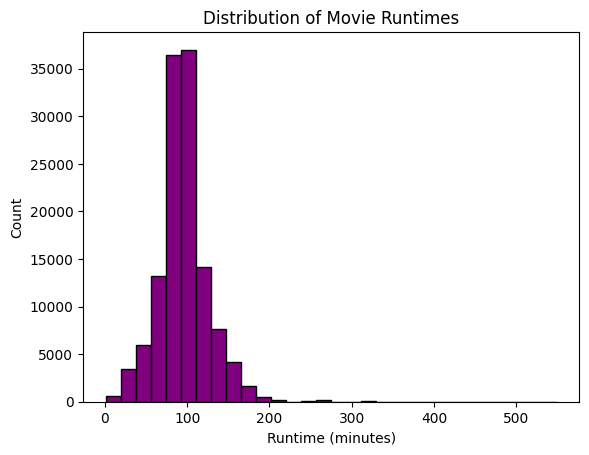

In [40]:
# Runtime Distribution
plt.hist(merged_df['runtime'].dropna(), bins=30, color='purple', edgecolor='black')
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Count')
plt.show()

#### Chart - 4 Top 10 Genres by Count

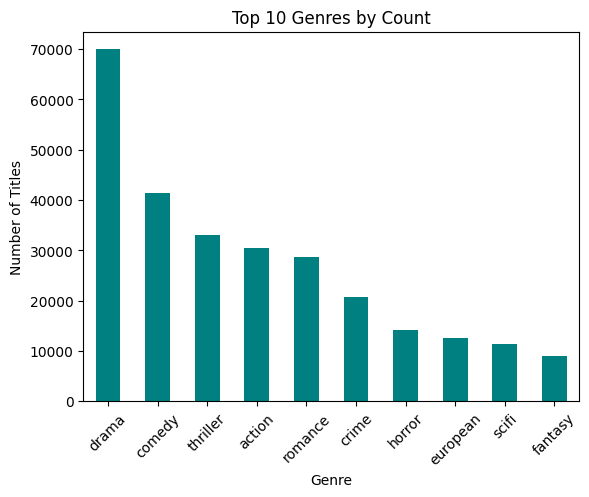

In [41]:
# Top 10 Genres by Count
genres_split['genres'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Genres by Count')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

#### Chart - 5 Average IMDb by Genre (Top 10)

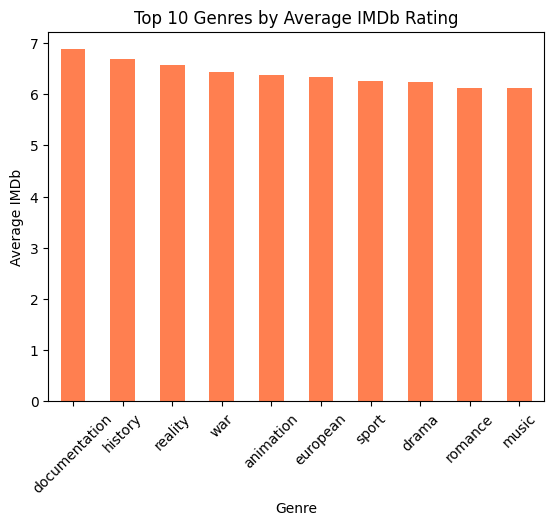

In [42]:
# Average IMDb by Genre (Top 10)
avg_imdb_genre.head(10).plot(kind='bar', color='coral')
plt.title('Top 10 Genres by Average IMDb Rating')
plt.xlabel('Genre')
plt.ylabel('Average IMDb')
plt.xticks(rotation=45)
plt.show()

#### Chart - 6 Genre vs IMDb Heatmap

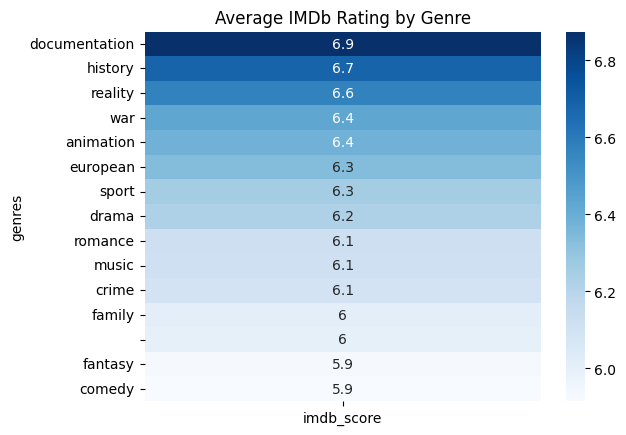

In [43]:
# Genre vs IMDb Heatmap
genre_pivot = genres_split.pivot_table(index='genres', values='imdb_score', aggfunc='mean').sort_values('imdb_score', ascending=False).head(15)
sns.heatmap(genre_pivot, annot=True, cmap='Blues')
plt.title('Average IMDb Rating by Genre')
plt.show()

#### Chart - 7 IMDb Score Distribution

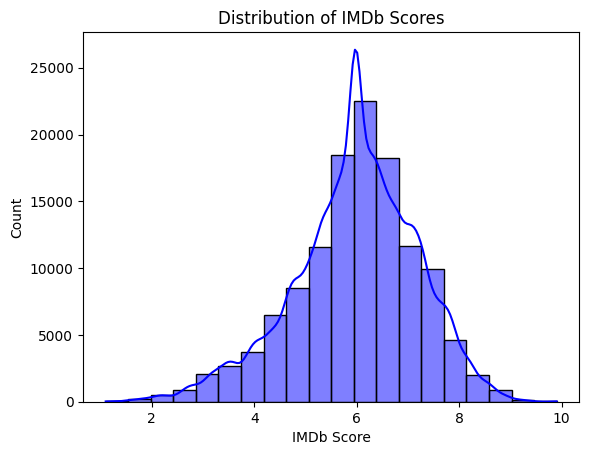

In [44]:
# IMDb Score Distribution
sns.histplot(merged_df['imdb_score'], bins=20, kde=True, color='blue')
plt.title('Distribution of IMDb Scores')
plt.xlabel('IMDb Score')
plt.ylabel('Count')
plt.show()


#### Chart - 8 IMDb vs TMDB Correlation Scatterplot

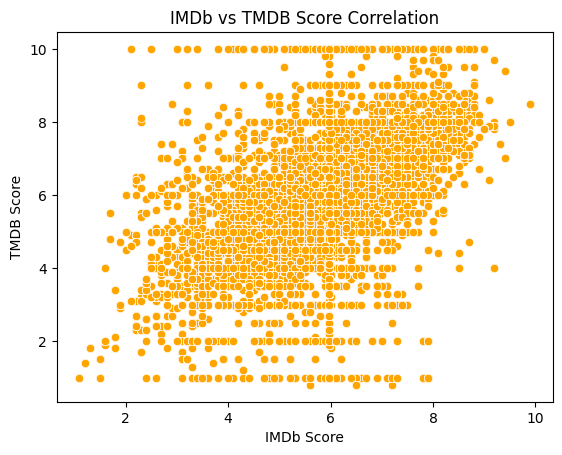

In [45]:
# IMDb vs TMDB Correlation Scatterplot
sns.scatterplot(data=merged_df, x='imdb_score', y='tmdb_score', color='orange')
plt.title('IMDb vs TMDB Score Correlation')
plt.xlabel('IMDb Score')
plt.ylabel('TMDB Score')
plt.show()

#### Chart - 9 Sort dataset by IMDb score (descending)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16160\3326259244.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


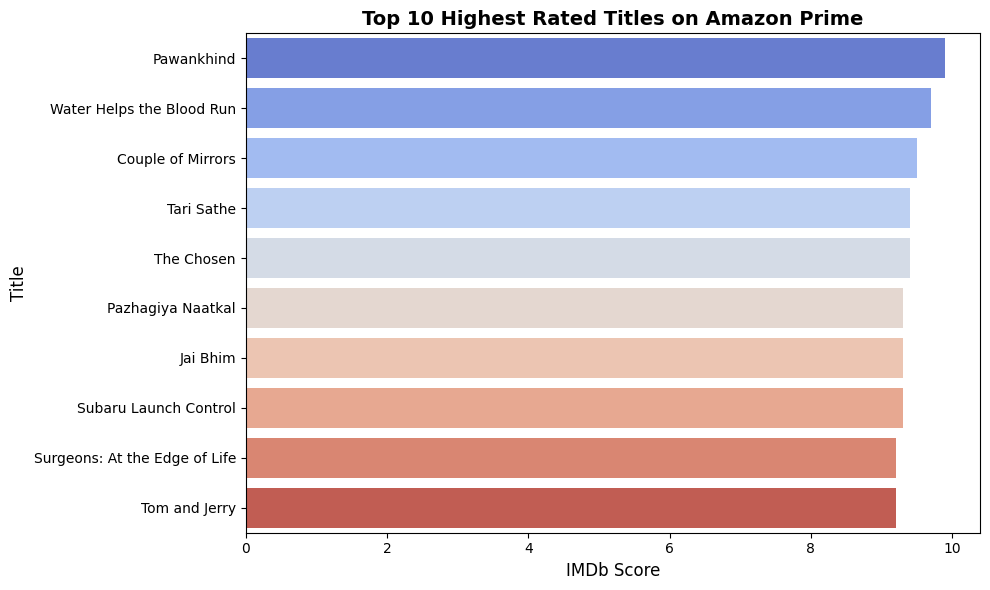

In [46]:
# Remove duplicate titles (created after merging with credits)
top_rated = (
    merged_df
    .drop_duplicates(subset='id')
    .sort_values('imdb_score', ascending=False)
    .head(10)
)

# Create bar chart
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_rated,
    x='imdb_score',
    y='title',
    palette='coolwarm'
)

# Chart labels and title
plt.title('Top 10 Highest Rated Titles on Amazon Prime', fontsize=14, weight='bold')
plt.xlabel('IMDb Score', fontsize=12)
plt.ylabel('Title', fontsize=12)

plt.tight_layout()
plt.show()

#### Chart - 10 Top 10 Actors

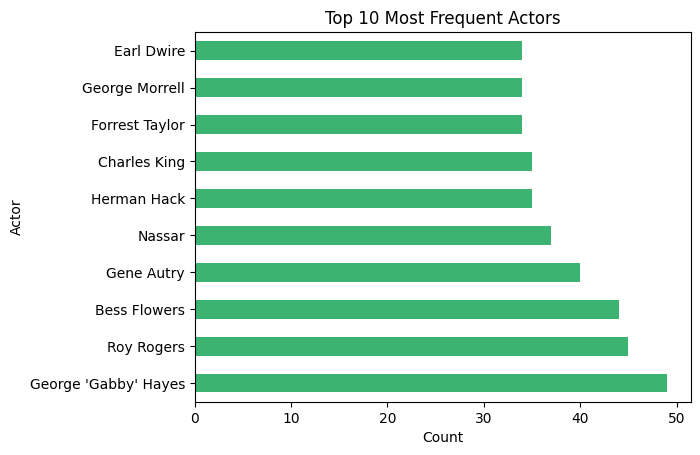

In [47]:
# Top 10 Actors
top_actors.plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Most Frequent Actors')
plt.xlabel('Count')
plt.ylabel('Actor')
plt.show()


#### Chart - 11 Top 10 Directors

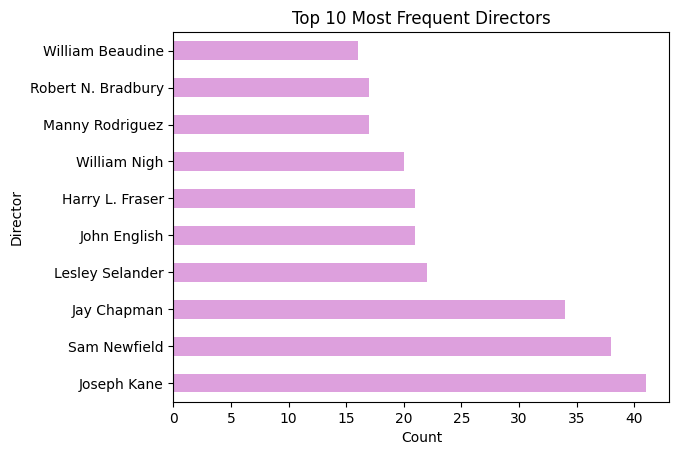

In [48]:
# Top 10 Directors
top_directors.plot(kind='barh', color='plum')
plt.title('Top 10 Most Frequent Directors')
plt.xlabel('Count')
plt.ylabel('Director')
plt.show()

#### Chart - 12 Role Distribution

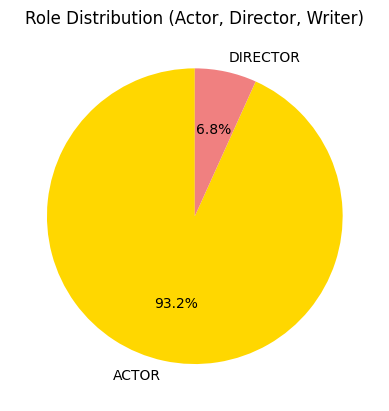

In [49]:
# Role Distribution
role_dist.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['gold', 'lightcoral', 'lightskyblue'])
plt.title('Role Distribution (Actor, Director, Writer)')
plt.ylabel('')
plt.show()

#### Chart - 13 Top 10 Production Countries

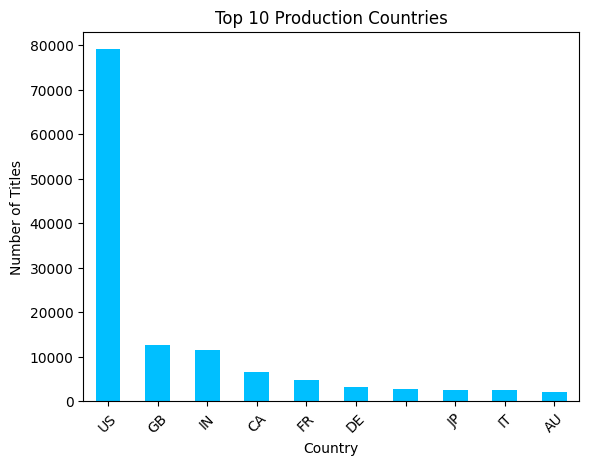

In [50]:
# Top 10 Production Countries
top_countries.plot(kind='bar', color='deepskyblue')
plt.title('Top 10 Production Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

#### Chart - 14 - Average IMDb by Country

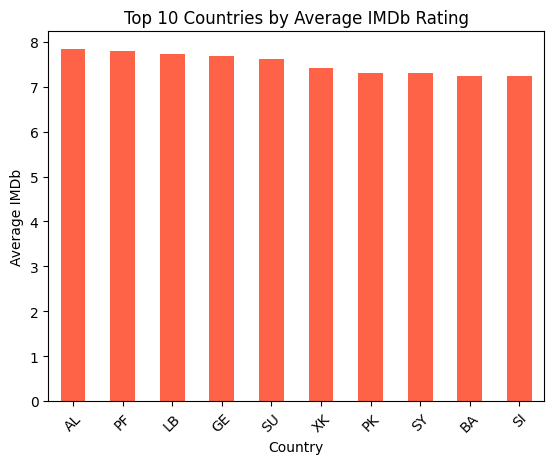

In [51]:
# Average IMDb by Country
avg_imdb_country = countries_split.groupby('production_countries')['imdb_score'].mean().sort_values(ascending=False).head(10)
avg_imdb_country.plot(kind='bar', color='tomato')
plt.title('Top 10 Countries by Average IMDb Rating')
plt.xlabel('Country')
plt.ylabel('Average IMDb')
plt.xticks(rotation=45)
plt.show()

#### Chart - 15 - Certification Distribution

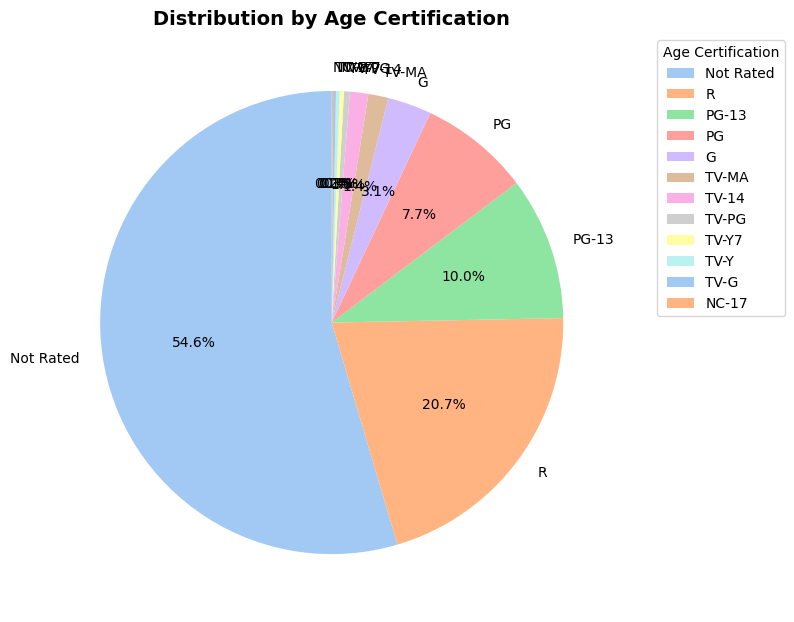

In [52]:
plt.figure(figsize=(8,8))

merged_df['age_certification'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)

plt.legend(title='Age Certification', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Distribution by Age Certification', fontsize=14, weight='bold')
plt.ylabel('')

plt.tight_layout()
plt.show()

#### Chart - 16 - Average IMDb by Certification

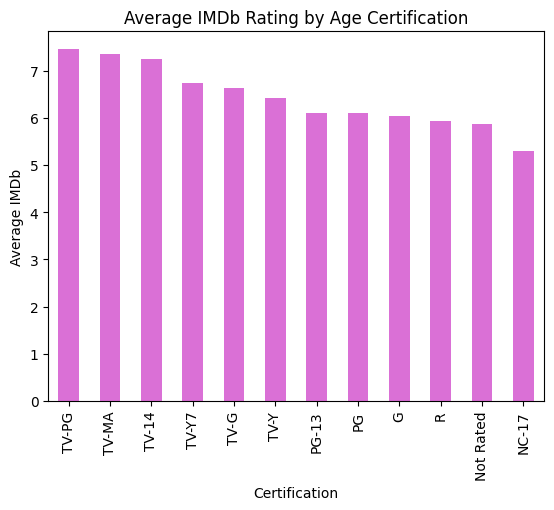

In [53]:
# Average IMDb by Certification

avg_imdb_cert.plot(kind='bar', color='orchid')
plt.title('Average IMDb Rating by Age Certification')
plt.xlabel('Certification')
plt.ylabel('Average IMDb')
plt.show()


#### Chart - 17 - Top 10 Popular Titles

C:\Users\Admin\AppData\Local\Temp\ipykernel_16160\508709983.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


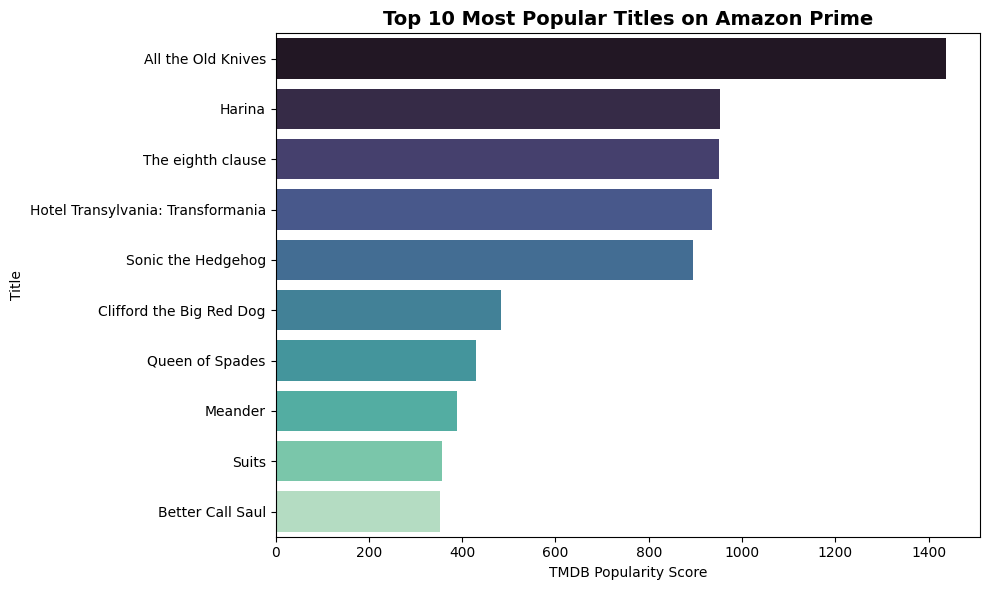

In [54]:
top_popular = (
    merged_df
    .drop_duplicates(subset='id')
    .sort_values('tmdb_popularity', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_popular,
    x='tmdb_popularity',
    y='title',
    order=top_popular['title'],
    palette='mako'
)

plt.title('Top 10 Most Popular Titles on Amazon Prime', fontsize=14, weight='bold')
plt.xlabel('TMDB Popularity Score')
plt.ylabel('Title')

plt.tight_layout()
plt.show()

#### Chart - 18 - Popularity vs IMDb Scatterplot

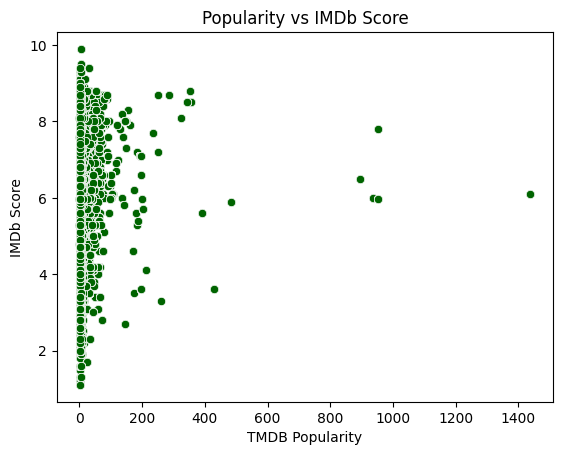

In [55]:
# Popularity vs IMDb Scatterplot
sns.scatterplot(data=merged_df, x='tmdb_popularity', y='imdb_score', color='darkgreen')
plt.title('Popularity vs IMDb Score')
plt.xlabel('TMDB Popularity')
plt.ylabel('IMDb Score')
plt.show()

#### Chart - 19 - IMDb Votes Trend (if available)

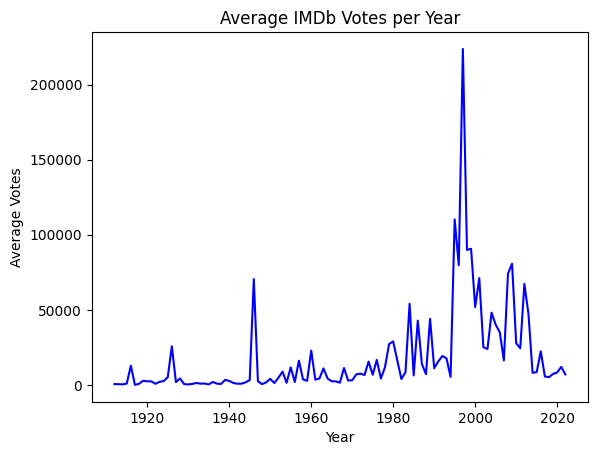

In [56]:
# IMDb Votes Trend (if available)
if 'imdb_votes' in merged_df.columns:
    merged_df.groupby('release_year')['imdb_votes'].mean().plot(kind='line', color='blue')
    plt.title('Average IMDb Votes per Year')
    plt.xlabel('Year')
    plt.ylabel('Average Votes')
    plt.show()


#### Chart - 20 - Total Releases per Year

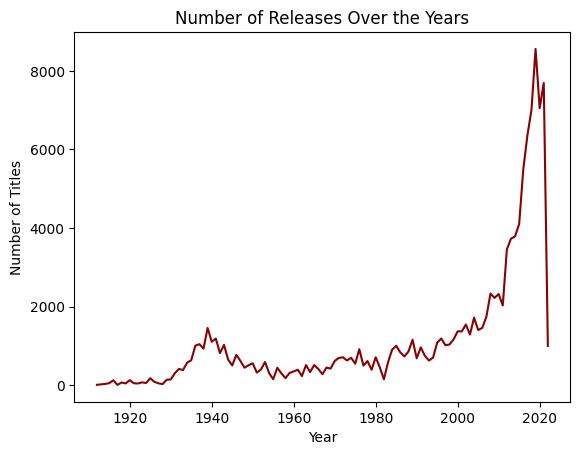

In [57]:
# Total Releases per Year
merged_df['release_year'].value_counts().sort_index().plot(kind='line', color='darkred')
plt.title('Number of Releases Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

#### Chart - 21 - Average IMDb per Year

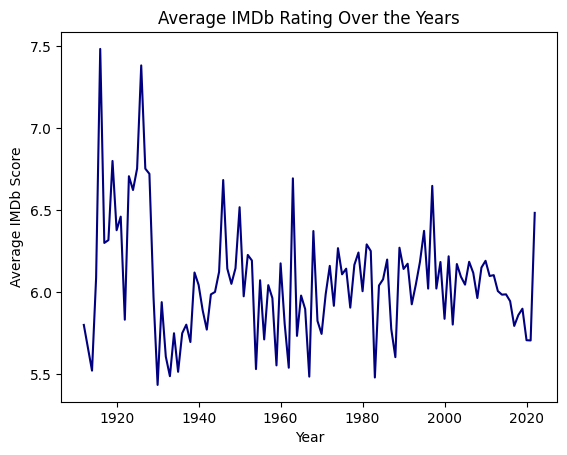

In [58]:
# Average IMDb per Year
avg_imdb_year.plot(kind='line', color='navy')
plt.title('Average IMDb Rating Over the Years')
plt.xlabel('Year')
plt.ylabel('Average IMDb Score')
plt.show()

#### Chart - 22-Runtime Trend Over Years

In [ ]:
# Runtime Trend Over Years
sns.lineplot(data=merged_df, x='release_year', y='runtime', color='teal')
plt.title('Average Runtime Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Runtime (minutes)')
plt.show()


#### Chart - 23 - Average IMDb by Rating Category

In [ ]:
# Average IMDb by Rating Category
avg_rating_category.plot(kind='bar', color='salmon')
plt.title('Average IMDb by Rating Category')
plt.xlabel('Rating Category')
plt.ylabel('Average IMDb')
plt.show()

#### Chart - 24 - Average Runtime by Runtime Category

In [ ]:
# Average Runtime by Runtime Category
avg_runtime_category.plot(kind='bar', color='lightblue')
plt.title('Average Runtime by Runtime Category')
plt.xlabel('Runtime Category')
plt.ylabel('Average Runtime (minutes)')
plt.show()

#### Chart - 25 - Runtime vs IMDb Scatter

In [ ]:
# Runtime vs IMDb Scatter
sns.scatterplot(data=merged_df, x='runtime', y='imdb_score', color='purple')
plt.title('Runtime vs IMDb Score')
plt.xlabel('Runtime')
plt.ylabel('IMDb Score')
plt.show()

## **6. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

## Business Recommendations

Based on the insights derived from the analysis, Amazon Prime Video can enhance its content strategy by focusing on genres, content types, and production regions that demonstrate strong audience interest and engagement. Prioritizing investments in highly rated and widely viewed categories can help maximize viewer satisfaction and platform usage.

The company can also benefit from partnering with directors, actors, and creators associated with successful titles, as their involvement often contributes to content popularity and audience appeal. Furthermore, leveraging rating metrics such as IMDb and TMDB scores can improve recommendation systems, enabling more personalized viewing experiences for users.

Maintaining a diverse content portfolio that includes both newly released titles and well-established classics can help attract and retain viewers with varying preferences. Continuous monitoring of content performance and audience trends will allow the platform to adapt its offerings to changing consumer demands.

By utilizing data-driven insights to guide content acquisition, production, and recommendation strategies, Amazon Prime Video can strengthen user engagement, improve customer retention, and reinforce its competitive position within the global streaming industry.